# De l'alpha à l'exécution : un pipeline complet de construction de portefeuille
### Étude méthodologique et validation — décision de mise en production

**Univers** : BNB, ETH, LINK, SOL (spot, données Binance 2022–2026) &nbsp;·&nbsp; **Fréquence** : barres journalières, rebalancement hebdomadaire &nbsp;·&nbsp; **Contraintes** : *long-only + cash*.

---

Ce notebook implémente **from scratch** (numpy / scipy / pandas uniquement — aucune boîte noire) la chaîne
canonique d'un moteur d'allocation quantitatif :

$$
\underbrace{\text{Prévision des rendements}}_{\text{alpha } \hat\mu}
\;\to\;
\underbrace{\text{Prévision de la volatilité}}_{\hat\sigma}
\;\to\;
\underbrace{\text{Prévision des corrélations}}_{\hat\rho \;\Rightarrow\; \hat\Sigma}
\;\to\;
\underbrace{\text{Optimisation du portefeuille}}_{w^\star}
\;\to\;
\underbrace{\text{Coûts de transaction}}_{\text{TC}}
\;\to\;
\underbrace{\text{Exécution optimale}}_{\text{Almgren–Chriss}}
$$

**Objectif pédagogique** : pour *chaque* étage, on donne l'**intuition**, la **formule**, l'**implémentation**
et une **validation quantitative** (hors-échantillon). L'objectif opérationnel : décider, preuves à l'appui,
si cette stratégie mérite un passage en production (paper-trading puis capital réel).

> ⚠️ **Principe directeur — pas de look-ahead.** À chaque date de décision $t$, tout ce qui entre dans
> $\hat\mu_t, \hat\Sigma_t, w_t$ n'utilise que l'information disponible **strictement avant** $t$.
> Toute la validation est *walk-forward* : les modèles sont ré-estimés à chaque rebalancement sur le seul passé.

## 0. Pourquoi ce découpage ? (la thèse méthodologique)

Le rendement d'un portefeuille de poids $w$ sur une période est $r_p = w^\top r$. Sa performance ajustée du
risque — le **ratio de Sharpe** — s'écrit

$$
\text{SR} \;=\; \frac{w^\top \mu - r_f}{\sqrt{w^\top \Sigma\, w}} .
$$

On ne connaît jamais $\mu$ (rendements espérés) ni $\Sigma$ (matrice de covariance) : on les **prévoit**.
Markowitz (1952) nous dit *quoi* faire de ces estimations ; le problème pratique est que
l'optimiseur est un **amplificateur d'erreur d'estimation** — il surpondère précisément les actifs dont
l'espérance de rendement est surestimée et la variance sous-estimée. D'où le pipeline :

| Étage | Question | Difficulté | Réponse dans ce notebook |
|---|---|---|---|
| **Alpha** $\hat\mu$ | quels actifs vont surperformer ? | *très* dur (faible ratio signal/bruit) | facteurs momentum/reversal + ridge |
| **Volatilité** $\hat\sigma$ | quelle amplitude de risque ? | modérée (vol = persistante) | EWMA vs GARCH(1,1) |
| **Corrélation** $\hat\rho$ | comment les actifs bougent ensemble ? | dure (matrice mal conditionnée) | shrinkage Ledoit–Wolf |
| **Optimisation** $w^\star$ | comment allouer ? | dépend de la robustesse | HRP, BL, robuste (Michaud) |
| **Coûts** | l'alpha survit-il au trading ? | souvent fatal | modèle linéaire + impact |
| **Exécution** | comment trader sans bouger le marché ? | micro-structure | Almgren–Chriss |

**Insight central** : plus on descend dans le pipeline, plus l'estimation est *fiable*. La volatilité se
prévoit bien mieux que le rendement. Les meilleures méthodes d'allocation (risk-parity, HRP) exploitent
ce fait en s'appuyant surtout sur $\Sigma$ et **peu ou pas** sur $\mu$. On testera empiriquement cette thèse.

## 1. Setup, chargement et qualité des données

On repart des OHLCV bruts Binance (barres 4h), qu'on **ré-échantillonne en journalier**. Le crypto se traite
24/7 : une année compte donc $\approx 365$ jours de trading (facteur d'annualisation).

In [1]:
%matplotlib inline
import os
import warnings
import numpy as np
import pandas as pd
import scipy.optimize as sco
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
import matplotlib as mpl

warnings.filterwarnings("ignore")
np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

RNG = np.random.default_rng(42)          # générateur reproductible
plt.rcParams.update({
    "figure.figsize": (11, 4.5), "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 11,
})

# --- paramètres globaux de l'étude ------------------------------------------
ASSETS       = ["BNBUSDT", "ETHUSDT", "LINKUSDT", "SOLUSDT"]
SRC_TF       = "4h"        # timeframe source à ré-échantillonner
ANNUAL       = 365         # crypto = 24/7
REBAL_STEP   = 7           # rebalancement toutes les 7 barres journalières (hebdo)
ALPHA_H      = 7           # horizon de prévision de l'alpha (jours) = période de détention
COV_LOOKBACK = 180         # fenêtre (jours) pour estimer la covariance
WARMUP       = 220         # barres de chauffe avant le début du backtest OOS
TARGET_VOL   = 0.50        # volatilité annualisée cible de l'overlay (crypto)
FEE          = 0.0010      # frais Binance ~10 bps par trade
HALF_SPREAD  = 0.0005      # demi-spread / slippage ~5 bps
IMPACT_COEF  = 0.02        # coefficient d'impact non-linéaire (modèle de coût)
RISK_FREE    = 0.0         # taux sans risque (cash / stablecoin) — approx 0


def _find_data_dir():
    """Trouve data_raw/ que le notebook tourne depuis la racine ou depuis notebooks/."""
    for c in ("data_raw", os.path.join("..", "data_raw"),
              os.path.join(os.path.dirname(os.path.abspath("__file__")), "..", "data_raw")):
        if os.path.isdir(c):
            return c
    raise FileNotFoundError("Dossier data_raw/ introuvable.")


DATA_DIR = _find_data_dir()
print("Données :", os.path.abspath(DATA_DIR))

Données : C:\Users\Osiris\Documents\Tangier\data_raw


In [2]:
def load_daily(assets, tf, data_dir):
    """Charge les OHLCV 4h et ré-échantillonne en prix de clôture journaliers alignés."""
    close, vol = {}, {}
    for a in assets:
        fp = os.path.join(data_dir, f"{a}_{tf}_raw.csv")
        df = (pd.read_csv(fp, parse_dates=["Date"]).set_index("Date").sort_index())
        close[a] = df["Close"].resample("1D").last()
        vol[a]   = df["Volume"].resample("1D").sum()
    px = pd.DataFrame(close).dropna(how="any")          # dates communes aux 4 actifs
    vv = pd.DataFrame(vol).reindex(px.index)
    return px, vv


PX, VOL = load_daily(ASSETS, SRC_TF, DATA_DIR)
R  = PX.pct_change().dropna()          # rendements simples (comptabilité du portefeuille)
LR = np.log(PX / PX.shift(1)).dropna() # log-rendements (modélisation de la vol)

print(f"Période      : {PX.index[0].date()} → {PX.index[-1].date()}")
print(f"Observations : {len(PX)} jours,  {len(ASSETS)} actifs")
print("\nAperçu des prix :")
print(PX.head(3).to_string())
print("\nStatistiques des rendements journaliers (%) :")
desc = (R * 100).describe().T[["mean", "std", "min", "max"]]
desc["ann_return_%"] = R.mean() * ANNUAL * 100
desc["ann_vol_%"]    = R.std() * np.sqrt(ANNUAL) * 100
desc["sharpe_bh"]    = (R.mean() * ANNUAL) / (R.std() * np.sqrt(ANNUAL))
print(desc.to_string())

Période      : 2022-01-01 → 2026-02-12
Observations : 1504 jours,  4 actifs

Aperçu des prix :
            BNBUSDT    ETHUSDT  LINKUSDT  SOLUSDT
Date                                             
2022-01-01 527.3000 3,765.5400   20.7600 179.0600
2022-01-02 531.0000 3,828.2700   21.8700 176.3500
2022-01-03 511.9000 3,765.8900   23.7200 170.1500

Statistiques des rendements journaliers (%) :
           mean    std      min     max  ann_return_%  ann_vol_%  sharpe_bh
BNBUSDT  0.0569 3.0413 -18.3568 17.3023       20.7571    58.1047     0.3572
ETHUSDT  0.0247 3.6888 -17.3843 21.8805        9.0207    70.4753     0.1280
LINKUSDT 0.0494 4.6866 -21.2824 33.3510       18.0284    89.5376     0.2013
SOLUSDT  0.0776 5.0915 -42.2477 32.5314       28.3422    97.2726     0.2914


### 1.1 Contrôles qualité

Avant toute modélisation : détecter trous de dates, prix aberrants, rendements impossibles. Un pipeline de
prod échoue le plus souvent **en amont**, sur des données sales (splits, ticks manquants, feed gelé).

Contrôles qualité
------------------------------------------------------------
Trous de dates (>1j)          : 0
Rendements |r| > 40%/jour     : {'BNBUSDT': 0, 'ETHUSDT': 0, 'LINKUSDT': 0, 'SOLUSDT': 1}
Prix <= 0                     : 0
NaN résiduels                 : 0


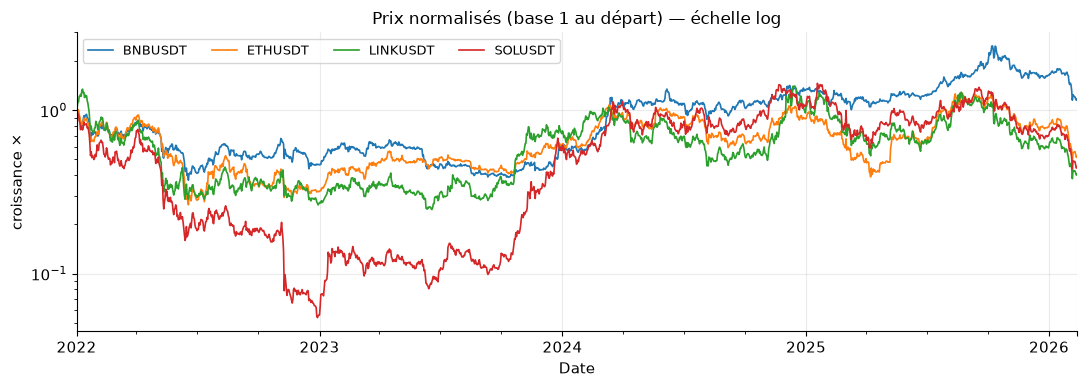

In [3]:
gaps = PX.index.to_series().diff().dt.days.fillna(1)
print("Contrôles qualité")
print("-" * 60)
print(f"Trous de dates (>1j)          : {(gaps > 1).sum()}")
print(f"Rendements |r| > 40%/jour     : {(R.abs() > 0.40).sum().to_dict()}")
print(f"Prix <= 0                     : {(PX <= 0).sum().sum()}")
print(f"NaN résiduels                 : {PX.isna().sum().sum()}")

fig, ax = plt.subplots(figsize=(11, 4))
(PX / PX.iloc[0]).plot(ax=ax, lw=1.2)
ax.set_title("Prix normalisés (base 1 au départ) — échelle log", fontsize=12)
ax.set_yscale("log"); ax.set_ylabel("croissance ×"); ax.legend(ncol=4, fontsize=9)
plt.tight_layout(); plt.show()

## 2. Étage 1 — Prévision des rendements (**alpha**)

### 2.1 Intuition
Prévoir le rendement d'un actif est le maillon **le plus difficile** : le ratio signal/bruit journalier est
minuscule (le "bruit" — la volatilité — écrase le "signal" — la dérive). On ne cherche donc pas à prédire
précisément, mais à extraire un **léger biais directionnel exploitable**. Deux régularités empiriques robustes
sur les cryptos :

- **Momentum** (Jegadeesh–Titman 1993) : les tendances à moyen terme (1–3 mois) persistent.
- **Reversal court terme** (Lehmann 1990) : sur quelques jours, les mouvements extrêmes se corrigent.

### 2.2 Formalisation — modèle factoriel linéaire
On construit pour chaque actif $i$ et chaque date $t$ un vecteur de **facteurs** $x_{i,t}$, et on modélise le
rendement **futur** sur l'horizon $H$ :

$$
r^{(H)}_{i,t} \;=\; \frac{P_{i,t+H}}{P_{i,t}} - 1 \;=\; x_{i,t}^\top \beta \;+\; \varepsilon_{i,t}.
$$

Facteurs retenus (tous calculés avec l'information **jusqu'à** $t$) :

$$
x_{i,t} = \Big[\underbrace{\tfrac{P_t}{P_{t-20}}-1}_{\text{mom. 20j}},\;
\underbrace{\tfrac{P_t}{P_{t-60}}-1}_{\text{mom. 60j}},\;
\underbrace{-\big(\tfrac{P_t}{P_{t-5}}-1\big)}_{\text{reversal 5j}},\;
\underbrace{\text{std}_{20}(r)}_{\text{risque}}\Big].
$$

### 2.3 Estimation — régression ridge (régularisée)
On estime $\beta$ par **moindres carrés régularisés** (ridge, Tikhonov). La pénalité $\lambda\lVert\beta\rVert^2$
stabilise les coefficients quand les facteurs sont corrélés et empêche le sur-ajustement :

$$
\hat\beta \;=\; \arg\min_{\beta}\; \lVert y - X\beta\rVert_2^2 + \lambda\lVert\beta\rVert_2^2
\;=\; (X^\top X + \lambda I)^{-1} X^\top y .
$$

**Pooling** : avec seulement 4 actifs, on **empile** (panel) les observations de tous les actifs pour estimer
un $\beta$ commun → beaucoup plus d'échantillon, coefficients stables. **Embargo** : à la date de décision $t$,
on n'entraîne que sur des cibles dont l'horizon se termine avant $t$ (on retire les $H$ derniers jours) pour
éviter le chevauchement train/test.

In [4]:
def build_features(px, rets):
    """Retourne un dict {actif -> DataFrame de features} et {actif -> rendement forward H}."""
    feats, fwd = {}, {}
    for a in px.columns:
        p = px[a]
        f = pd.DataFrame(index=px.index)
        f["mom20"] = p / p.shift(20) - 1.0
        f["mom60"] = p / p.shift(60) - 1.0
        f["rev5"]  = -(p / p.shift(5) - 1.0)
        f["vol20"] = rets[a].rolling(20).std()
        feats[a] = f
        fwd[a] = p.shift(-ALPHA_H) / p - 1.0     # cible : rendement futur sur H jours
    return feats, fwd


FEATURES, FWD = build_features(PX, R)
FEAT_COLS = ["mom20", "mom60", "rev5", "vol20"]


def ridge_fit_predict(x_tr, y_tr, x_pred, lam=15.0):
    """Ridge avec standardisation des features (stats calculées sur le train uniquement)."""
    mu, sd = x_tr.mean(0), x_tr.std(0) + 1e-9
    xs = (x_tr - mu) / sd
    ym = y_tr.mean()
    k = xs.shape[1]
    beta = np.linalg.solve(xs.T @ xs + lam * np.eye(k), xs.T @ (y_tr - ym))
    return ((x_pred - mu) / sd) @ beta + ym, beta


_ALPHA_CACHE = {}


def alpha_at(date_pos, lam=15.0):
    """Prévision d'alpha (rendement H-jours) pour chaque actif à la position temporelle `date_pos`,
    entraînée uniquement sur le passé (avec embargo de ALPHA_H jours). Renvoie (alpha_vec, beta).
    Mémoïsée : les mêmes dates réapparaissent dans la validation IC et le backtest."""
    key = (int(date_pos), lam)
    if key in _ALPHA_CACHE:
        return _ALPHA_CACHE[key]
    cutoff = date_pos - ALPHA_H                      # embargo anti-chevauchement
    x_tr, y_tr = [], []
    x_pred = []
    for a in ASSETS:
        F = FEATURES[a].values
        y = FWD[a].values
        rows = np.arange(60, cutoff)                 # 60 = chauffe des features (mom60)
        m = rows[np.isfinite(F[rows]).all(1) & np.isfinite(y[rows])]
        x_tr.append(F[m]); y_tr.append(y[m])
        x_pred.append(F[date_pos])
    x_tr = np.vstack(x_tr); y_tr = np.concatenate(y_tr)
    x_pred = np.vstack(x_pred)
    pred, beta = ridge_fit_predict(x_tr, y_tr, x_pred, lam)
    _ALPHA_CACHE[key] = (pred, beta)
    return pred, beta


# démonstration : alpha à la dernière date
demo_alpha, demo_beta = alpha_at(len(PX) - 1)
print("Coefficients ridge (panel, dernière date) :")
for c, b in zip(FEAT_COLS, demo_beta):
    print(f"   {c:8s} : {b:+.4f}")
print("\nAlpha prévu (rendement attendu sur 7 j, %) :")
for a, v in zip(ASSETS, demo_alpha):
    print(f"   {a:9s} : {v*100:+.2f}%")

Coefficients ridge (panel, dernière date) :
   mom20    : +0.0064
   mom60    : -0.0013
   rev5     : +0.0014
   vol20    : -0.0008

Alpha prévu (rendement attendu sur 7 j, %) :
   BNBUSDT   : -0.36%
   ETHUSDT   : -0.47%
   LINKUSDT  : -0.37%
   SOLUSDT   : -0.54%


### 2.4 Validation de l'alpha — l'*Information Coefficient* (IC)

Un alpha ne se juge pas à son $R^2$ (quasi nul et trompeur) mais à sa capacité de **classement** : les actifs
à alpha élevé surperforment-ils réellement ? On mesure l'**IC**, corrélation entre alpha prévu et rendement
réalisé, calculée **hors-échantillon** sur toutes les dates de rebalancement :

$$
\text{IC} \;=\; \text{corr}\big(\hat\alpha_{i,t},\; r^{(H)}_{i,t}\big).
$$

Règle de pouce (equities) : $\text{IC} \approx 0.03\text{–}0.06$ est déjà exploitable. La *loi fondamentale de
la gestion active* (Grinold) relie le Sharpe atteignable à l'IC et au nombre de paris indépendants $N$ :
$\text{IR} \approx \text{IC}\,\sqrt{N}$. Avec 4 actifs, $N$ est faible — on ne s'attend pas à des miracles côté
alpha, ce qui **motive** de s'appuyer surtout sur le risque (étages suivants).

IC poolé (toutes obs OOS)      : -0.0340
IC moyen par date              : -0.0044
IC IR (moyenne/écart-type)     : -0.007
Hit rate directionnel          : 47.0%


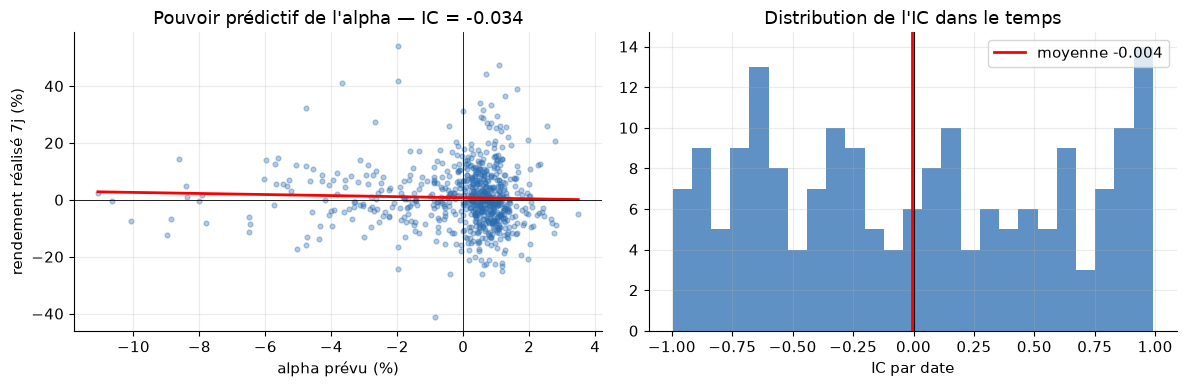

In [5]:
# IC hors-échantillon sur toutes les dates de rebalancement (walk-forward, léger sous-échantillonnage)
oos_positions = np.arange(WARMUP, len(PX) - ALPHA_H, REBAL_STEP)
pred_all, real_all, ic_per_date = [], [], []
for pos in oos_positions:
    a_pred, _ = alpha_at(pos)
    a_real = np.array([FWD[a].values[pos] for a in ASSETS])
    if np.isfinite(a_real).all():
        pred_all.append(a_pred); real_all.append(a_real)
        if np.std(a_pred) > 0 and np.std(a_real) > 0:
            ic_per_date.append(np.corrcoef(a_pred, a_real)[0, 1])

pred_all = np.concatenate(pred_all); real_all = np.concatenate(real_all)
ic_pooled = np.corrcoef(pred_all, real_all)[0, 1]
ic_mean   = np.mean(ic_per_date)
ic_ir     = ic_mean / (np.std(ic_per_date) + 1e-9)   # "IC IR" ~ stabilité du signal
hit       = np.mean(np.sign(pred_all) == np.sign(real_all))

print(f"IC poolé (toutes obs OOS)      : {ic_pooled:+.4f}")
print(f"IC moyen par date              : {ic_mean:+.4f}")
print(f"IC IR (moyenne/écart-type)     : {ic_ir:+.3f}")
print(f"Hit rate directionnel          : {hit*100:.1f}%")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(pred_all * 100, real_all * 100, s=12, alpha=0.35, color="#2b6cb0")
b1, b0 = np.polyfit(pred_all, real_all, 1)
xs = np.linspace(pred_all.min(), pred_all.max(), 50)
ax[0].plot(xs * 100, (b0 + b1 * xs) * 100, "r-", lw=2)
ax[0].axhline(0, color="k", lw=.6); ax[0].axvline(0, color="k", lw=.6)
ax[0].set_xlabel("alpha prévu (%)"); ax[0].set_ylabel("rendement réalisé 7j (%)")
ax[0].set_title(f"Pouvoir prédictif de l'alpha — IC = {ic_pooled:+.3f}")
ax[1].hist(ic_per_date, bins=25, color="#2b6cb0", alpha=.75)
ax[1].axvline(ic_mean, color="r", lw=2, label=f"moyenne {ic_mean:+.3f}")
ax[1].axvline(0, color="k", lw=.8)
ax[1].set_xlabel("IC par date"); ax[1].set_title("Distribution de l'IC dans le temps"); ax[1].legend()
plt.tight_layout(); plt.show()

## 3. Étage 2 — Prévision de la **volatilité**

### 3.1 Intuition
Contrairement au rendement, la volatilité est **fortement persistante** et prévisible : les marchés alternent
régimes calmes et agités (*volatility clustering*, Mandelbrot 1963). C'est le maillon le plus **fiable** du
pipeline — d'où son rôle central dans le contrôle du risque.

### 3.2 Trois estimateurs

**(a) Fenêtre glissante** (naïf) : $\hat\sigma_t^2 = \frac{1}{n}\sum_{k=1}^{n} r_{t-k}^2$. Simple mais réagit
brutalement (effet "fenêtre" : un choc entre et sort d'un coup).

**(b) EWMA / RiskMetrics** : pondération exponentielle du passé,

$$
\hat\sigma_t^2 \;=\; \lambda\,\hat\sigma_{t-1}^2 \;+\; (1-\lambda)\, r_{t-1}^2,\qquad \lambda = 0.94.
$$

Réactif et sans paramètre à estimer — le standard de l'industrie pour un premier jet.

**(c) GARCH(1,1)** (Bollerslev 1986) — le modèle de référence. La variance suit un processus autorégressif :

$$
\hat\sigma_t^2 \;=\; \omega \;+\; \alpha\, r_{t-1}^2 \;+\; \beta\, \hat\sigma_{t-1}^2,
\qquad \omega>0,\ \alpha,\beta\ge 0,\ \alpha+\beta<1.
$$

- $\alpha$ = réaction aux chocs récents, $\beta$ = mémoire/persistance.
- $\alpha+\beta$ proche de 1 ⇒ vol très persistante. Variance de long terme : $\bar\sigma^2 = \omega/(1-\alpha-\beta)$.
- Estimation par **maximum de vraisemblance** (hypothèse gaussienne) :
$\;\ell(\theta) = -\tfrac12\sum_t\big[\ln(2\pi) + \ln\hat\sigma_t^2 + r_t^2/\hat\sigma_t^2\big].$

In [6]:
def ewma_vol(r, lam=0.94):
    """Volatilité EWMA (RiskMetrics). r : array de rendements. Renvoie la série de sigma."""
    r = np.asarray(r, float)
    var = np.empty(len(r)); var[0] = np.var(r[:20]) if len(r) > 20 else np.var(r)
    for t in range(1, len(r)):
        var[t] = lam * var[t - 1] + (1 - lam) * r[t - 1] ** 2
    return np.sqrt(var)


def garch11_fit(r):
    """Estime GARCH(1,1) par MLE gaussien (rendements en %, pour la stabilité numérique)."""
    x = np.asarray(r, float) * 100.0
    n = len(x); uncond = np.var(x)

    def negloglik(p):
        omega, alpha, beta = p
        var = np.empty(n); var[0] = uncond
        for t in range(1, n):
            var[t] = omega + alpha * x[t - 1] ** 2 + beta * var[t - 1]
        var = np.clip(var, 1e-12, None)
        return 0.5 * np.sum(np.log(2 * np.pi) + np.log(var) + x ** 2 / var)

    res = sco.minimize(
        negloglik, x0=[uncond * 0.05, 0.05, 0.90], method="SLSQP",
        bounds=[(1e-8, None), (0, 1), (0, 1)],
        constraints=[{"type": "ineq", "fun": lambda p: 0.999 - p[1] - p[2]}],
        options={"maxiter": 300, "ftol": 1e-9},
    )
    omega, alpha, beta = res.x
    return dict(omega=omega, alpha=alpha, beta=beta, scale=100.0,
                persistence=alpha + beta,
                uncond_vol=np.sqrt(omega / max(1 - alpha - beta, 1e-6)) / 100.0)


def garch11_filter(r, params):
    """Applique la récursion GARCH (paramètres fixes) et renvoie sigma journalier (échelle d'origine)."""
    x = np.asarray(r, float) * params["scale"]
    n = len(x); var = np.empty(n); var[0] = np.var(x)
    for t in range(1, n):
        var[t] = params["omega"] + params["alpha"] * x[t - 1] ** 2 + params["beta"] * var[t - 1]
    return np.sqrt(var) / params["scale"]


# Ajustement GARCH par actif sur une portion "train", diagnostic des paramètres
print("Paramètres GARCH(1,1) estimés par actif :")
print(f"{'actif':10s} {'omega':>10s} {'alpha':>8s} {'beta':>8s} {'α+β':>8s} {'vol_LT_ann':>12s}")
garch_params = {}
split = int(len(LR) * 0.6)
for a in ASSETS:
    p = garch11_fit(LR[a].values[:split])
    garch_params[a] = p
    print(f"{a:10s} {p['omega']:10.4f} {p['alpha']:8.3f} {p['beta']:8.3f} "
          f"{p['persistence']:8.3f} {p['uncond_vol']*np.sqrt(ANNUAL)*100:11.1f}%")

Paramètres GARCH(1,1) estimés par actif :


actif           omega    alpha     beta      α+β   vol_LT_ann
BNBUSDT        0.8552    0.215    0.727    0.942        73.4%
ETHUSDT        0.4786    0.092    0.874    0.965        70.9%
LINKUSDT       2.9096    0.140    0.716    0.855        85.7%
SOLUSDT        4.0814    0.196    0.675    0.871       107.5%


### 3.3 Validation de la vol — réaliser "la vérité" avec les barres 4h

La volatilité est **latente** : on ne l'observe jamais directement. Astuce clé : on dispose des barres **4h**
(6 par jour). La **variance réalisée** journalière $\text{RV}_t = \sum_{j} r_{t,j}^2$ (somme des rendements
intra-journaliers au carré) est un proxy **beaucoup plus précis** de la vraie variance que le simple $r_t^2$.
On l'utilise comme cible pour comparer les prévisions un-pas-en-avant, via la perte **QLIKE** (robuste, standard
pour la vol) et la MSE :

$$
\text{QLIKE} = \frac{1}{T}\sum_t \Big(\frac{\text{RV}_t}{\hat\sigma_t^2} - \ln\frac{\text{RV}_t}{\hat\sigma_t^2} - 1\Big),
\qquad \text{MSE} = \frac{1}{T}\sum_t (\text{RV}_t - \hat\sigma_t^2)^2 .
$$

Plus c'est **bas**, mieux c'est. QLIKE pénalise fortement la sous-estimation du risque (ce qui compte pour
la gestion des pertes).

Qualité de prévision de la volatilité — QLIKE (plus bas = mieux)
          QLIKE_roll  QLIKE_ewma  QLIKE_garch
actif                                        
BNBUSDT       0.7859      0.7299       0.6598
ETHUSDT       0.7154      0.7088       0.6906
LINKUSDT      0.6054      0.5673       0.5576
SOLUSDT       0.5379      0.5010       0.5075

Meilleur modèle par actif : {'BNBUSDT': 'QLIKE_garch', 'ETHUSDT': 'QLIKE_garch', 'LINKUSDT': 'QLIKE_garch', 'SOLUSDT': 'QLIKE_ewma'}


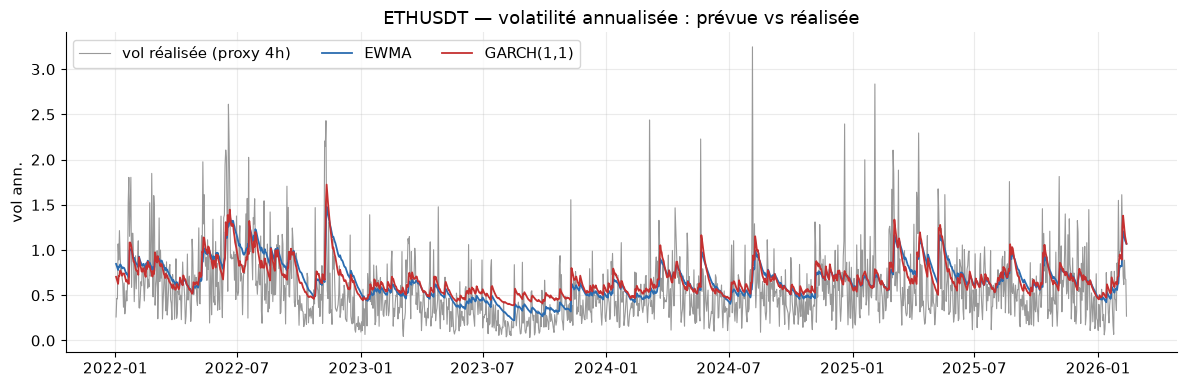

In [7]:
def realized_var_daily(asset, tf="4h"):
    """Variance réalisée journalière à partir des rendements intra-journaliers (barres 4h)."""
    fp = os.path.join(DATA_DIR, f"{asset}_{tf}_raw.csv")
    df = pd.read_csv(fp, parse_dates=["Date"]).set_index("Date").sort_index()
    lr = np.log(df["Close"] / df["Close"].shift(1))
    return (lr ** 2).resample("1D").sum()


def qlike(rv, var_hat):
    m = (rv > 0) & (var_hat > 0) & np.isfinite(rv) & np.isfinite(var_hat)
    z = rv[m] / var_hat[m]
    return np.mean(z - np.log(z) - 1)


rows = []
for a in ASSETS:
    rv = realized_var_daily(a).reindex(LR.index).values
    r = LR[a].values
    # prévisions un-pas-en-avant sur la portion test
    s_roll = pd.Series(r).rolling(20).std().shift(1).values
    s_ewma = np.concatenate([[np.nan], ewma_vol(r, 0.94)[:-1]])         # sigma_t utilise info < t
    s_garch = np.concatenate([[np.nan], garch11_filter(r, garch_params[a])[:-1]])
    test = slice(split, len(r))
    rv_t = rv[test]
    rows.append({
        "actif": a,
        "QLIKE_roll":  qlike(rv_t, s_roll[test] ** 2),
        "QLIKE_ewma":  qlike(rv_t, s_ewma[test] ** 2),
        "QLIKE_garch": qlike(rv_t, s_garch[test] ** 2),
    })
vol_eval = pd.DataFrame(rows).set_index("actif")
print("Qualité de prévision de la volatilité — QLIKE (plus bas = mieux)")
print(vol_eval.to_string())
print("\nMeilleur modèle par actif :", vol_eval.idxmin(axis=1).to_dict())

# illustration : ETH, vol prévue vs réalisée
a = "ETHUSDT"
rv = np.sqrt(realized_var_daily(a).reindex(LR.index).values) * np.sqrt(ANNUAL)
fig, ax = plt.subplots(figsize=(12, 4))
idx = LR.index
ax.plot(idx, rv, color="0.6", lw=.8, label="vol réalisée (proxy 4h)")
ax.plot(idx, ewma_vol(LR[a].values, .94) * np.sqrt(ANNUAL), color="#2b6cb0", lw=1.3, label="EWMA")
ax.plot(idx, garch11_filter(LR[a].values, garch_params[a]) * np.sqrt(ANNUAL), color="#c53030", lw=1.3, label="GARCH(1,1)")
ax.set_title(f"{a} — volatilité annualisée : prévue vs réalisée"); ax.set_ylabel("vol ann.")
ax.legend(ncol=3); plt.tight_layout(); plt.show()

## 4. Étage 3 — Prévision des **corrélations** → matrice de covariance

### 4.1 Le problème du conditionnement
La covariance $\Sigma$ combine volatilités et corrélations : $\Sigma = D\,C\,D$ avec $D=\text{diag}(\sigma)$ et
$C$ la matrice de corrélation. L'optimiseur a besoin de $\Sigma^{-1}$ ; or la covariance **empirique** est
bruitée et souvent **mal conditionnée** (quasi-singulière) — surtout quand le nombre d'actifs $N$ approche le
nombre d'observations. L'inversion amplifie alors le bruit → poids extrêmes et instables.

### 4.2 Solution : le *shrinkage* de Ledoit–Wolf (2004)
On "rétrécit" la covariance empirique $S$ vers une cible structurée $F$ bien conditionnée (ici, l'identité
mise à l'échelle $F=\mu I$, $\mu=\text{tr}(S)/N$) :

$$
\hat\Sigma \;=\; \delta\,F \;+\; (1-\delta)\,S,\qquad \delta\in[0,1].
$$

L'intensité optimale $\delta^\star$ **minimise l'erreur quadratique attendue** $\mathbb{E}\lVert\hat\Sigma-\Sigma\rVert_F^2$
et admet une forme close (estimateur de Ledoit–Wolf) :

$$
\delta^\star = \frac{\hat b^2}{\hat d^2},\quad
\hat d^2 = \lVert S-\mu I\rVert_F^2,\quad
\hat b^2 = \min\!\Big(\hat d^2,\ \tfrac{1}{T^2}\sum_{k}\lVert r_k r_k^\top - S\rVert_F^2\Big).
$$

Interprétation : plus $S$ est bruité (échantillon court), plus $\delta^\star \to 1$ (on fait confiance à la
structure). C'est un compromis **biais–variance** optimal, appliqué à l'estimation de matrice.

Intensité de shrinkage δ* = 0.041
Conditionnement  empirique =     38.6
Conditionnement  Ledoit-Wolf =     26.7   (plus bas = plus stable)


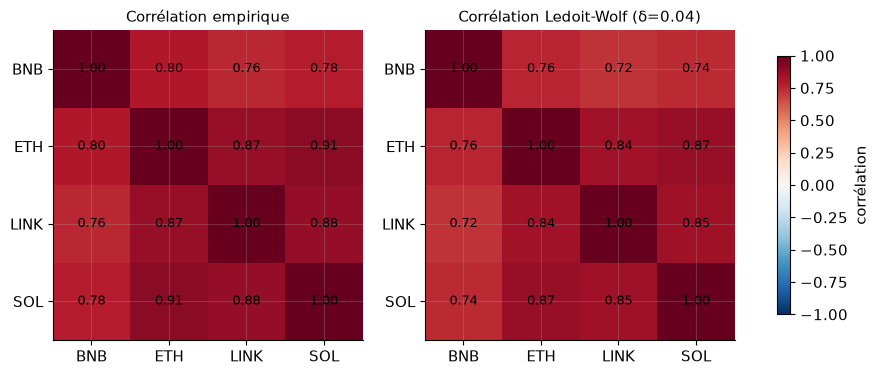

In [8]:
def ledoit_wolf_cov(returns):
    """Shrinkage linéaire de Ledoit–Wolf vers l'identité mise à l'échelle.
    returns : (T, N). Renvoie (Sigma_shrink, delta)."""
    X = np.asarray(returns, float)
    X = X - X.mean(0, keepdims=True)
    T, N = X.shape
    S = (X.T @ X) / T
    mu = np.trace(S) / N
    d2 = np.sum((S - mu * np.eye(N)) ** 2)
    # b2_bar = (1/T^2) sum_k ||x_k x_k^T - S||_F^2, vectorisé
    norm2 = np.sum(X ** 2, axis=1)                       # ||x_k||^2
    term_a = np.sum(norm2 ** 2)                          # sum ||x_k x_k^T||^2
    term_b = np.sum(np.einsum("ki,ij,kj->k", X, S, X))   # sum x_k^T S x_k
    b2_bar = (term_a - 2 * term_b + T * np.sum(S ** 2)) / (T ** 2)
    b2 = min(b2_bar, d2)
    delta = 0.0 if d2 <= 0 else b2 / d2
    Sigma = delta * mu * np.eye(N) + (1 - delta) * S
    return Sigma, float(delta)


def cov_to_corr(cov):
    d = np.sqrt(np.diag(cov))
    return cov / np.outer(d, d)


# comparaison covariance empirique vs shrinkée sur une fenêtre récente
win = R.values[-COV_LOOKBACK:]
S_emp = np.cov(win.T)
S_lw, delta = ledoit_wolf_cov(win)
print(f"Intensité de shrinkage δ* = {delta:.3f}")
print(f"Conditionnement  empirique = {np.linalg.cond(S_emp):8.1f}")
print(f"Conditionnement  Ledoit-Wolf = {np.linalg.cond(S_lw):8.1f}   (plus bas = plus stable)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, C, ttl in [(axes[0], cov_to_corr(S_emp), "Corrélation empirique"),
                   (axes[1], cov_to_corr(S_lw), f"Corrélation Ledoit-Wolf (δ={delta:.2f})")]:
    im = ax.imshow(C, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_xticks(range(len(ASSETS))); ax.set_yticks(range(len(ASSETS)))
    ax.set_xticklabels([a[:-4] for a in ASSETS]); ax.set_yticklabels([a[:-4] for a in ASSETS])
    for i in range(len(ASSETS)):
        for j in range(len(ASSETS)):
            ax.text(j, i, f"{C[i,j]:.2f}", ha="center", va="center", fontsize=9)
    ax.set_title(ttl, fontsize=11)
fig.colorbar(im, ax=axes, shrink=0.8, label="corrélation")
plt.show()

## 5. Étage 4 — Optimisation du portefeuille

On dispose maintenant de $\hat\mu$ (alpha) et $\hat\Sigma$ (covariance shrinkée). Reste à choisir $w$.
**Contraintes de l'étude** (long-only + cash) : $w_i \ge 0$ et $\sum_i w_i \le 1$ (le reste $1-\sum w_i$ va
en cash, sans risque). On sépare proprement **composition** (comment répartir la poche risquée, $\sum=1$) et
**dosage du risque** (overlay de vol qui décide de la part risquée vs cash).

On implémente **6 méthodes**, du plus au moins dépendant de l'alpha :

### 5.1 Min-Variance & Risk-Parity — n'utilisent **que** $\Sigma$

**Minimum-variance** : le portefeuille de plus faible risque, indépendant de tout alpha.
$$ w^\star = \arg\min_w\; w^\top\Sigma w \quad \text{s.c. } \mathbf 1^\top w = 1,\ w\ge 0. $$

**Risk-Parity** (parité du risque) : chaque actif contribue **également** au risque total. La contribution au
risque de l'actif $i$ est $\text{RC}_i = w_i\,(\Sigma w)_i / \sqrt{w^\top\Sigma w}$. On cherche $\text{RC}_i =
\text{RC}_j\ \forall i,j$. Plus robuste que min-variance (ne mise pas tout sur l'actif le moins volatil).

In [9]:
_SLSQP = {"maxiter": 60, "ftol": 1e-8}   # bornes de convergence (rapidité)


def _clean_w(w):
    w = np.clip(np.asarray(w, float), 0, None)
    s = w.sum()
    return w / s if s > 1e-12 else np.ones_like(w) / len(w)


def w_equal(cov=None, mu=None):
    n = len(ASSETS); return np.ones(n) / n


def w_inverse_vol(cov, mu=None):
    iv = 1.0 / np.sqrt(np.diag(cov))
    return iv / iv.sum()


def w_min_variance(cov, mu=None):
    n = len(cov)
    res = sco.minimize(lambda w: w @ cov @ w, np.ones(n) / n, method="SLSQP",
                       bounds=[(0, 1)] * n, options=_SLSQP,
                       constraints=[{"type": "eq", "fun": lambda w: w.sum() - 1}])
    return _clean_w(res.x)


def w_risk_parity(cov, mu=None):
    n = len(cov)

    def obj(w):
        w = np.abs(w) + 1e-12
        pv = w @ cov @ w
        rc = w * (cov @ w) / pv          # contributions au risque NORMALISÉES (somment à 1)
        return np.sum((rc - 1.0 / n) ** 2)   # objectif à l'échelle O(1) -> convergence saine

    res = sco.minimize(obj, np.ones(n) / n, method="SLSQP", bounds=[(1e-6, 1)] * n,
                       options={"maxiter": 200, "ftol": 1e-12},
                       constraints=[{"type": "eq", "fun": lambda w: w.sum() - 1}])
    return _clean_w(res.x)

### 5.2 HRP — *Hierarchical Risk Parity* (López de Prado 2016)

HRP contourne l'inversion de $\Sigma$ (source d'instabilité) par une approche en **3 temps**, fondée sur la
structure de corrélation :

1. **Clustering hiérarchique** : distance entre actifs $d_{ij}=\sqrt{\tfrac12(1-\rho_{ij})}$, puis arbre
   d'agrégation (linkage). Les actifs qui bougent ensemble sont regroupés.
2. **Quasi-diagonalisation** : on réordonne la matrice pour que les actifs similaires soient adjacents.
3. **Bissection récursive** : on descend l'arbre en répartissant le budget de risque entre les deux
   sous-groupes **inversement à leur variance** (inverse-variance allocation).

Résultat : une allocation **diversifiée et stable**, sans jamais inverser la covariance — d'où sa robustesse
quand $N$ est petit ou la matrice bruitée.

In [10]:
def _quasi_diag(link):
    link = link.astype(int)
    n = link[-1, 3]
    order = list(link[-1, :2])
    while max(order) >= n:
        new = []
        for v in order:
            if v < n:
                new.append(v)
            else:
                a, b = link[v - n, 0], link[v - n, 1]
                new.extend([a, b])
        order = new
    return order


def _cluster_var(cov, items):
    c = cov[np.ix_(items, items)]
    iv = 1.0 / np.diag(c); iv /= iv.sum()
    return float(iv @ c @ iv)


def w_hrp(cov, mu=None):
    corr = cov_to_corr(cov)
    dist = np.sqrt(np.clip(0.5 * (1 - corr), 0, None))
    link = linkage(squareform(dist, checks=False), method="single")
    order = _quasi_diag(link)
    w = np.ones(len(cov))
    clusters = [order]
    while clusters:
        clusters = [c[s] for c in clusters
                    for s in (slice(0, len(c) // 2), slice(len(c) // 2, None)) if len(c) > 1]
        for i in range(0, len(clusters), 2):
            c0, c1 = clusters[i], clusters[i + 1]
            v0, v1 = _cluster_var(cov, c0), _cluster_var(cov, c1)
            a = 1 - v0 / (v0 + v1)
            for k in c0: w[k] *= a
            for k in c1: w[k] *= (1 - a)
    return _clean_w(w)

### 5.3 Max-Sharpe & Black–Litterman — intègrent l'**alpha**

**Max-Sharpe (tangence)** : maximise le ratio de Sharpe ex-ante $\dfrac{w^\top\mu}{\sqrt{w^\top\Sigma w}}$.
Puissant mais **fragile** : très sensible aux erreurs sur $\mu$.

**Black–Litterman (1992)** : le remède élégant. Au lieu de prendre l'alpha brut, on **mélange bayésiennement** :

- un *a priori* d'équilibre $\pi = \delta\,\Sigma\,w_{\text{mkt}}$ (rendements implicites du portefeuille neutre,
  ici équipondéré), avec $\delta$ l'aversion au risque ;
- nos *vues* $Q$ (l'alpha), d'incertitude $\Omega$.

Le rendement *a posteriori* combine les deux, pondérés par leurs précisions (matrice $P=I$, vues absolues) :

$$
\mu_{\text{BL}} = \Big[(\tau\Sigma)^{-1} + P^\top\Omega^{-1}P\Big]^{-1}
\Big[(\tau\Sigma)^{-1}\pi + P^\top\Omega^{-1}Q\Big].
$$

On optimise ensuite en max-Sharpe sur $\mu_{\text{BL}}$. Avantage : les poids restent **proches du neutre**
et ne partent dans un actif que si la vue est à la fois forte *et* confiante. Fini les coins de portefeuille.

In [11]:
def w_max_sharpe(cov, mu):
    n = len(cov)
    if mu is None or np.allclose(mu, 0):
        return w_min_variance(cov)

    def neg_sr(w):
        v = np.sqrt(w @ cov @ w)
        return -(w @ mu) / (v + 1e-12)

    res = sco.minimize(neg_sr, np.ones(n) / n, method="SLSQP", bounds=[(0, 1)] * n,
                       options=_SLSQP,
                       constraints=[{"type": "eq", "fun": lambda w: w.sum() - 1}])
    w = res.x
    return _clean_w(w) if (w @ mu) > 0 else w_min_variance(cov)


def black_litterman_mu(cov, mu_views, w_mkt=None, delta=3.0, tau=0.05, view_conf=1.0):
    n = len(cov)
    if w_mkt is None:
        w_mkt = np.ones(n) / n
    pi = delta * cov @ w_mkt                       # rendements d'équilibre implicites
    P = np.eye(n); Q = np.asarray(mu_views, float)
    Omega = np.diag(np.diag(tau * P @ cov @ P.T)) / max(view_conf, 1e-6)
    tau_cov_inv = np.linalg.inv(tau * cov)
    M = np.linalg.inv(tau_cov_inv + P.T @ np.linalg.inv(Omega) @ P)
    return M @ (tau_cov_inv @ pi + P.T @ np.linalg.inv(Omega) @ Q)


def w_black_litterman(cov, mu):
    if mu is None:
        return w_min_variance(cov)
    mu_bl = black_litterman_mu(cov, mu, view_conf=0.5)
    return w_max_sharpe(cov, mu_bl)

### 5.4 Optimisation **robuste** (Michaud / resampling)

L'alpha $\hat\mu$ est une *estimation* : sa vraie valeur vit dans un nuage d'incertitude de covariance
$\approx \Sigma/T_{\text{est}}$. La *resampled efficiency* de Michaud (1998) intègre cette incertitude :

1. simuler $\hat\mu^{(b)} \sim \mathcal N(\hat\mu,\ \Sigma/T_{\text{est}})$ ;
2. optimiser (max-Sharpe) sur chaque tirage $\to w^{(b)}$ ;
3. moyenner : $w_{\text{robuste}} = \frac1B\sum_b w^{(b)}$.

La moyenne **lisse** les coins extrêmes : deux actifs quasi-substituables se partagent le poids au lieu que
l'optimiseur ne mette tout sur celui, par hasard, à l'alpha estimé le plus haut. C'est une réponse directe au
problème d'*amplification d'erreur* de Markowitz.

In [12]:
def w_robust(cov, mu, n_boot=25, t_est=COV_LOOKBACK):
    if mu is None:
        return w_min_variance(cov)
    acc = np.zeros(len(cov))
    sampling_cov = cov / t_est
    for _ in range(n_boot):
        mu_b = RNG.multivariate_normal(mu, sampling_cov)
        acc += w_max_sharpe(cov, mu_b)
    return _clean_w(acc / n_boot)


METHODS = {
    "EqualWeight":     w_equal,
    "InverseVol":      w_inverse_vol,
    "MinVariance":     w_min_variance,
    "RiskParity":      w_risk_parity,
    "HRP":             w_hrp,
    "MaxSharpe":       w_max_sharpe,
    "BlackLitterman":  w_black_litterman,
    "Robust":          w_robust,
}
ALPHA_METHODS = {"MaxSharpe", "BlackLitterman", "Robust"}   # méthodes qui consomment l'alpha

# aperçu : poids produits par chaque méthode sur la dernière fenêtre
cov_now, _ = ledoit_wolf_cov(R.values[-COV_LOOKBACK:])
mu_now = demo_alpha / ALPHA_H     # alpha ramené en rendement journalier
print("Poids de la poche risquée (dernière fenêtre) :")
print(f"{'méthode':16s} " + " ".join(f"{a[:-4]:>7s}" for a in ASSETS))
for name, fn in METHODS.items():
    w = fn(cov_now, mu_now) if name in ALPHA_METHODS else fn(cov_now)
    print(f"{name:16s} " + " ".join(f"{x:7.3f}" for x in w))

Poids de la poche risquée (dernière fenêtre) :
méthode              BNB     ETH    LINK     SOL
EqualWeight        0.250   0.250   0.250   0.250
InverseVol         0.291   0.256   0.218   0.235
MinVariance        0.750   0.250   0.000   0.000
RiskParity         0.304   0.250   0.216   0.230
HRP                0.351   0.246   0.196   0.207
MaxSharpe          0.750   0.250   0.000   0.000
BlackLitterman     0.189   0.197   0.378   0.236
Robust             0.439   0.178   0.184   0.198


### 5.5 Overlay de ciblage de volatilité (dosage risqué / cash)

Chaque méthode donne une **composition** ($\sum w=1$). On décide ensuite *combien* de capital exposer, en
visant une volatilité annualisée cible $\sigma^\star$ (ici 50 %). Part risquée :

$$
\phi_t = \min\!\Big(1,\ \frac{\sigma^\star}{\sqrt{w^\top\Sigma_t w}\,\sqrt{365}}\Big),
\qquad w^{\text{final}}_t = \phi_t\, w_t,\qquad \text{cash} = 1-\phi_t .
$$

Long-only : $\phi\le 1$ (pas de levier). Quand la vol prévue explose, on se réfugie mécaniquement en cash —
un **stop de risque** endogène, sans paramètre discrétionnaire.

In [13]:
def vol_target_overlay(w_risky, cov, target_vol=TARGET_VOL):
    port_vol_ann = np.sqrt(w_risky @ cov @ w_risky) * np.sqrt(ANNUAL)
    phi = min(1.0, target_vol / (port_vol_ann + 1e-12))
    return w_risky * phi          # somme <= 1, le reste est du cash

## 6. Étage 5 — Coûts de transaction

### 6.1 Pourquoi c'est souvent fatal
Une stratégie brillante sur le papier peut être **détruite** par les coûts. À chaque rebalancement, tourner le
portefeuille coûte. On modélise trois composantes, fonction du **turnover** $\text{TO}_t = \sum_i |w_{i,t}-w_{i,t^-}|$ :

$$
\text{TC}_t = \underbrace{f\cdot \text{TO}_t}_{\text{frais}} \;+\;
\underbrace{s\cdot \text{TO}_t}_{\text{spread/slippage}} \;+\;
\underbrace{\kappa \sum_i |w_{i,t}-w_{i,t^-}|^{3/2}}_{\text{impact marché (non-linéaire)}} .
$$

- $f=10$ bps (frais Binance), $s=5$ bps (demi-spread).
- L'impact marché est **convexe** (loi en 3/2, Almgren) : tourner deux fois plus coûte plus que le double.
- Le coût est déduit du rendement le jour du rebalancement.

### 6.2 Optimisation *cost-aware* (bandes de non-trading)
On peut réduire le turnover en pénalisant le déplacement : $w^\star=\arg\min_w w^\top\Sigma w + \gamma\lVert w-w^-\rVert_1$.
Effet : une **zone de non-trading** — on ne rebalance que si le gain dépasse le coût. On l'illustre plus bas.

In [14]:
def transaction_cost(w_new, w_old, fee=FEE, half_spread=HALF_SPREAD, impact=IMPACT_COEF):
    dw = np.abs(w_new - w_old)
    turnover = dw.sum()
    linear = (fee + half_spread) * turnover
    market_impact = impact * np.sum(dw ** 1.5)
    return linear + market_impact, turnover


def w_min_variance_costaware(cov, w_prev, gamma=0.02):
    """Min-variance avec pénalité L1 de turnover (crée une bande de non-trading).
    La variance est annualisée pour rendre gamma interprétable en unités de rendement."""
    n = len(cov)
    res = sco.minimize(lambda w: ANNUAL * (w @ cov @ w) + gamma * np.sum(np.abs(w - w_prev)),
                       w_prev.copy(), method="SLSQP", bounds=[(0, 1)] * n, options=_SLSQP,
                       constraints=[{"type": "eq", "fun": lambda w: w.sum() - 1}])
    return _clean_w(res.x)


# illustration : plus gamma est grand, moins on s'éloigne du portefeuille courant (bande de non-trading)
w_prev_demo = w_equal()
print("Effet de la pénalité de turnover (min-variance cost-aware, variance annualisée) :")
print(f"{'gamma':>8s} {'turnover':>10s} {'coût (bps)':>12s}")
for g in [0.0, 0.002, 0.01, 0.03, 0.10]:
    w = w_min_variance_costaware(cov_now, w_prev_demo, gamma=g) if g > 0 else w_min_variance(cov_now)
    c, to = transaction_cost(w, w_prev_demo)
    print(f"{g:8.3f} {to:10.3f} {c*1e4:12.1f}")

Effet de la pénalité de turnover (min-variance cost-aware, variance annualisée) :
   gamma   turnover   coût (bps)
   0.000      1.000        135.7
   0.002      1.012        137.3
   0.010      1.000        135.7
   0.030      0.883        113.7
   0.100      0.414         43.9


## 7. Étage 6 — Exécution optimale (Almgren–Chriss)

### 7.1 Le dilemme de l'exécution
Une fois $w^\star$ décidé, il faut **exécuter** les trades. Vendre trop vite ⇒ fort **impact marché** (on
écrase le prix). Vendre trop lentement ⇒ **risque de prix** (le marché bouge contre nous entre-temps). Almgren
& Chriss (2000) résolvent ce compromis optimalement.

### 7.2 Le modèle
Liquider $X$ unités en $N$ tranches sur $[0,T]$ ($\tau=T/N$). Impact temporaire linéaire $\eta$, volatilité
$\sigma$, aversion au risque $\lambda$. On minimise coût espéré **+** $\lambda\times$ variance. La trajectoire
d'inventaire optimale est **hyperbolique** :

$$
x_k = X\,\frac{\sinh\!\big(\kappa(T-t_k)\big)}{\sinh(\kappa T)},\qquad
\cosh(\kappa\tau) = 1 + \frac{\lambda\,\sigma^2\,\tau^2}{2\,\eta}.
$$

- $\lambda\to 0$ (indifférent au risque) ⇒ $\kappa\to 0$ ⇒ exécution **linéaire** (TWAP).
- $\lambda$ grand (averse) ⇒ exécution **front-loadée** (on vend vite pour couper le risque).

On applique le modèle au plus gros trade du dernier rebalancement et on compare à un TWAP naïf.

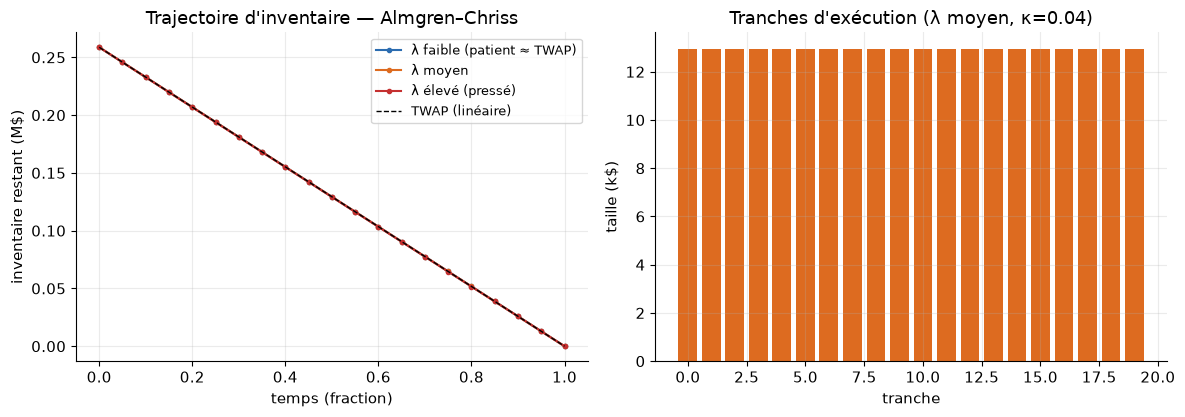

Book simulé 1 M$ · plus grosse ligne à exécuter : 259 k$ · σ_j ≈ 4.0%


In [15]:
def almgren_chriss(X, T=1.0, N=20, eta=2.5e-6, sigma=0.02, lam=2e-6):
    """Trajectoire d'inventaire optimale. Renvoie (temps, inventaire, tranches)."""
    tau = T / N
    kappa = np.arccosh(1 + (lam * sigma ** 2 * tau ** 2) / (2 * eta)) / tau
    t = np.linspace(0, T, N + 1)
    inv = X * np.sinh(kappa * (T - t)) / np.sinh(kappa * T)
    trades = -np.diff(inv)                 # taille de chaque tranche
    return t, inv, trades, kappa


# plus gros trade du dernier rebalancement -> notionnel illustratif
w_target = vol_target_overlay(w_hrp(cov_now), cov_now)
dw = w_target - np.r_[w_prev_demo * 0]     # depuis cash
biggest = np.abs(w_target).max()
X0 = biggest * 1_000_000                    # 1 M$ de book, plus grosse ligne
sigma_daily = float(np.sqrt(np.diag(cov_now)).mean())

fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
for lam, col, lbl in [(2e-7, "#2b6cb0", "λ faible (patient ≈ TWAP)"),
                      (2e-6, "#dd6b20", "λ moyen"),
                      (2e-5, "#c53030", "λ élevé (pressé)")]:
    t, inv, trades, kap = almgren_chriss(X0, N=20, sigma=sigma_daily, lam=lam)
    ax[0].plot(t, inv / 1e6, marker="o", ms=3, color=col, label=lbl)
    ax[1].bar(np.arange(len(trades)) + (0 if lam == 2e-6 else 0), trades / 1e3,
              alpha=0.0)  # placeholder pour garder l'échelle
t, inv, trades, kap = almgren_chriss(X0, N=20, sigma=sigma_daily, lam=2e-6)
ax[0].plot(t, X0 * (1 - t) / 1e6, "k--", lw=1, label="TWAP (linéaire)")
ax[0].set_title("Trajectoire d'inventaire — Almgren–Chriss"); ax[0].set_xlabel("temps (fraction)")
ax[0].set_ylabel("inventaire restant (M$)"); ax[0].legend(fontsize=9)
ax[1].bar(np.arange(len(trades)), trades / 1e3, color="#dd6b20")
ax[1].set_title(f"Tranches d'exécution (λ moyen, κ={kap:.2f})")
ax[1].set_xlabel("tranche"); ax[1].set_ylabel("taille (k$)")
plt.tight_layout(); plt.show()
print(f"Book simulé 1 M$ · plus grosse ligne à exécuter : {X0/1e3:.0f} k$ · σ_j ≈ {sigma_daily*100:.1f}%")

## 8. Validation — backtest walk-forward net de coûts

On assemble **tout** le pipeline dans un backtest honnête :

> **À chaque rebalancement hebdomadaire $t$** (walk-forward, *out-of-sample*) :
> 1. estimer $\hat\Sigma_t$ (Ledoit–Wolf sur les 180 derniers jours) et $\hat\mu_t$ (ridge sur le seul passé) ;
> 2. calculer la composition $w_t$ (chaque méthode) ; appliquer l'overlay de vol ;
> 3. déduire le **coût** du turnover vs $w_{t^-}$ ; détenir jusqu'à $t+7j$ ; encaisser $w_t^\top r_{[t,t+7]}$.

Aucune information future n'entre dans une décision. On compare **8 méthodes** + 2 benchmarks (équipondéré
investi à 100 %, et buy-&-hold ETH).

In [16]:
def precompute_rebal():
    """Passe LOURDE unique : à chaque rebalancement, estime covariance + alpha et calcule
    la composition (poids de poche risquée) de chaque méthode. On réutilise ensuite ce cache
    pour le backtest ET toute l'analyse de sensibilité (l'overlay et les coûts sont recalculés
    à la volée, sans ré-optimiser)."""
    positions = np.arange(WARMUP, len(PX) - 1, REBAL_STEP)
    precomp = []
    for pos in positions:
        cov, _ = ledoit_wolf_cov(R.values[pos - COV_LOOKBACK:pos])   # info < t seulement
        mu_daily = alpha_at(pos)[0] / ALPHA_H
        wr = {m: (METHODS[m](cov, mu_daily) if m in ALPHA_METHODS else METHODS[m](cov))
              for m in METHODS}
        precomp.append({"pos": int(pos), "cov": cov, "wr": wr})
    return positions, precomp


def backtest_from(precomp, positions, target_vol=TARGET_VOL, cost_mult=1.0):
    """Applique overlay de vol + coûts sur les compositions précalculées (rapide, sans optimisation)."""
    idx = PX.index
    R_arr = R.values                                    # numpy (évite le copy-on-write pandas)
    ret_arr = {m: np.zeros(len(idx)) for m in METHODS}
    whist = {m: [] for m in METHODS}
    prev = {m: np.zeros(len(ASSETS)) for m in METHODS}
    turn = {m: [] for m in METHODS}; cost = {m: [] for m in METHODS}
    dates = []
    for k, d in enumerate(precomp):
        pos, cov = d["pos"], d["cov"]
        end = int(positions[k + 1]) if k + 1 < len(positions) else len(PX) - 1
        dates.append(idx[pos])
        for m in METHODS:
            w_full = vol_target_overlay(d["wr"][m], cov, target_vol)   # part risquée + cash
            c, to = transaction_cost(w_full, prev[m])
            daily = R_arr[pos:end] @ w_full                            # cash = 0
            daily = daily.copy(); daily[0] -= c * cost_mult            # coût au 1er jour
            ret_arr[m][pos:end] = daily
            prev[m] = w_full
            whist[m].append(w_full); turn[m].append(to); cost[m].append(c)
    ret = {m: pd.Series(ret_arr[m], index=idx) for m in METHODS}
    for m in METHODS:
        whist[m] = pd.DataFrame(whist[m], index=dates, columns=ASSETS)
    bench = {}
    b_idx = slice(int(positions[0]), len(PX) - 1)
    bench["BM_EqualWeight_100%"] = (R.iloc[b_idx] @ (np.ones(len(ASSETS)) / len(ASSETS)))
    bench["BM_BuyHold_ETH"]      = R["ETHUSDT"].iloc[b_idx]
    return ret, whist, turn, cost, bench, dates


print("Précalcul walk-forward (une passe : covariance + alpha + optimisation par semaine)...")
POSITIONS, PRECOMP = precompute_rebal()
STRAT_RET, STRAT_W, TURN, COST, BENCH, REBAL_DATES = backtest_from(PRECOMP, POSITIONS)
print(f"OK — {len(REBAL_DATES)} rebalancements, "
      f"OOS du {REBAL_DATES[0].date()} au {PX.index[-1].date()}")

Précalcul walk-forward (une passe : covariance + alpha + optimisation par semaine)...


OK — 184 rebalancements, OOS du 2022-08-09 au 2026-02-12


In [17]:
def perf_metrics(daily, ann=ANNUAL, rf=RISK_FREE):
    d = pd.Series(daily).dropna()
    n = len(d)
    eq = (1 + d).cumprod()
    cagr = eq.iloc[-1] ** (ann / n) - 1
    vol = d.std() * np.sqrt(ann)
    sharpe = (d.mean() * ann - rf) / (d.std() * np.sqrt(ann) + 1e-12)
    downside = d[d < 0].std() * np.sqrt(ann)
    sortino = (d.mean() * ann - rf) / (downside + 1e-12)
    dd = eq / eq.cummax() - 1
    maxdd = dd.min()
    calmar = cagr / abs(maxdd) if maxdd < 0 else np.nan
    # erreur-type du Sharpe (Lo 2002) : SE ≈ sqrt((1 + SR^2/2)/n_years... ) en fréquence
    se_sharpe = np.sqrt((1 + 0.5 * sharpe ** 2) / n) * np.sqrt(ann)
    return dict(CAGR=cagr, Vol=vol, Sharpe=sharpe, Sortino=sortino,
                MaxDD=maxdd, Calmar=calmar, Sharpe_SE=se_sharpe)


rows = {}
for m in METHODS:
    r = STRAT_RET[m].loc[REBAL_DATES[0]:]
    met = perf_metrics(r)
    met["AvgTurnover"] = np.mean(TURN[m])
    met["CostDrag_ann_%"] = np.sum(COST[m]) / (len(REBAL_DATES) / (ANNUAL / REBAL_STEP)) * 100
    rows[m] = met
for b, r in BENCH.items():
    rows[b] = perf_metrics(r)

PERF = pd.DataFrame(rows).T
PERF_SHOW = PERF.copy()
for c in ["CAGR", "Vol", "MaxDD", "CostDrag_ann_%"]:
    if c in PERF_SHOW: PERF_SHOW[c] = (PERF_SHOW[c] * (100 if c != "CostDrag_ann_%" else 1)).round(1)
for c in ["Sharpe", "Sortino", "Calmar", "Sharpe_SE", "AvgTurnover"]:
    if c in PERF_SHOW: PERF_SHOW[c] = PERF_SHOW[c].round(2)
PERF_SHOW = PERF_SHOW.sort_values("Sharpe", ascending=False)
print("\n" + "=" * 92)
print("TABLEAU DE PERFORMANCE — walk-forward, net de coûts  (CAGR/Vol/MaxDD en %)")
print("=" * 92)
print(PERF_SHOW[["CAGR", "Vol", "Sharpe", "Sharpe_SE", "Sortino", "MaxDD", "Calmar",
                 "AvgTurnover", "CostDrag_ann_%"]].to_string())


TABLEAU DE PERFORMANCE — walk-forward, net de coûts  (CAGR/Vol/MaxDD en %)
                       CAGR     Vol  Sharpe  Sharpe_SE  Sortino    MaxDD  Calmar  AvgTurnover  CostDrag_ann_%
EqualWeight         27.5000 50.9000  0.7300     0.6000   1.0400 -50.6000  0.5400       0.0200          0.4000
InverseVol          25.2000 50.4000  0.7000     0.5900   0.9700 -51.2000  0.4900       0.0200          0.4000
RiskParity          25.5000 50.5000  0.7000     0.6000   0.9700 -51.4000  0.5000       0.0200          0.4000
HRP                 23.1000 50.1000  0.6700     0.5900   0.9100 -52.0000  0.4400       0.0300          0.7000
BM_EqualWeight_100% 19.8000 65.3000  0.6100     0.5800   0.8500 -61.0000  0.3300          NaN             NaN
MinVariance         16.0000 48.3000  0.5500     0.5700   0.7500 -51.4000  0.3100       0.0500          1.7000
Robust               9.3000 50.2000  0.4300     0.5600   0.6000 -53.1000  0.1700       0.3100         14.4000
BM_BuyHold_ETH       4.2000 66.4000  0.3900 

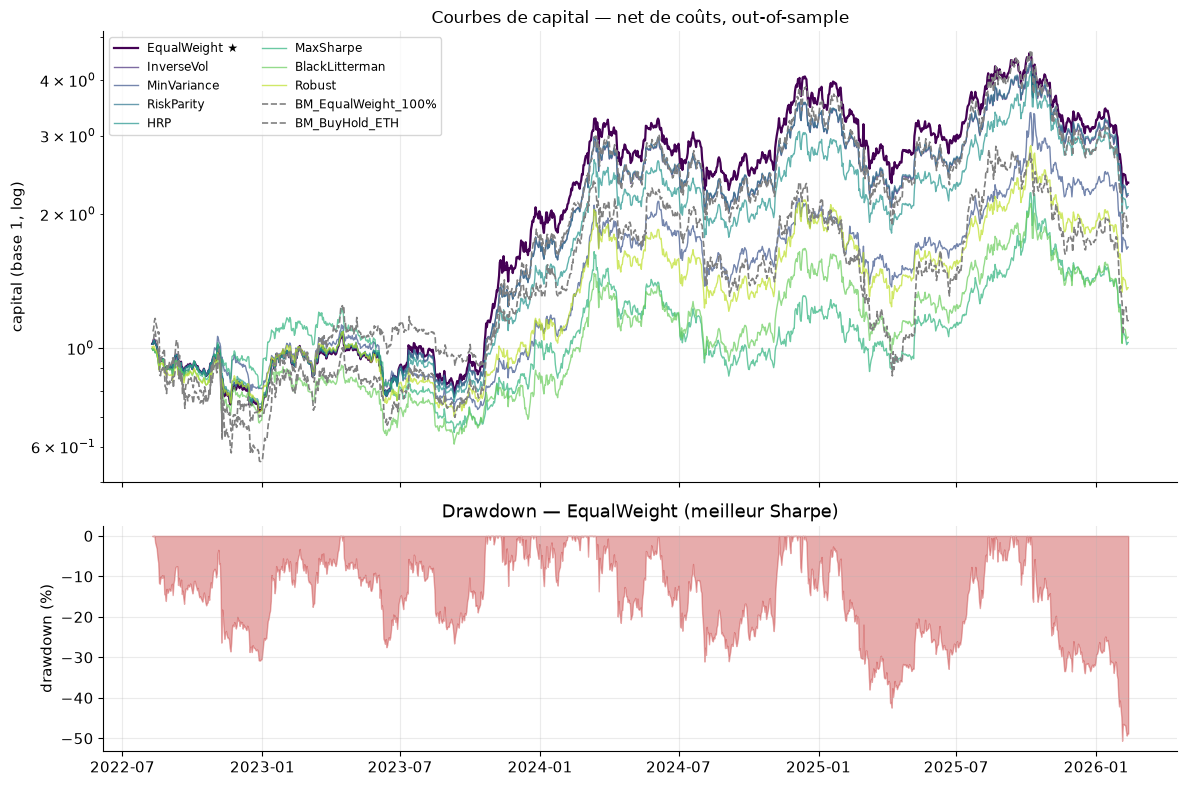

In [18]:
# Courbes de capital (échelle log) + drawdowns
best = PERF.drop(index=[b for b in BENCH]).sort_values("Sharpe", ascending=False).index[0]
palette = plt.cm.viridis(np.linspace(0, 0.9, len(METHODS)))
fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True, height_ratios=[2, 1])
for (m, c) in zip(METHODS, palette):
    eq = (1 + STRAT_RET[m].loc[REBAL_DATES[0]:]).cumprod()
    ax[0].plot(eq, color=c, lw=1.6 if m == best else 1.0,
               alpha=1.0 if m == best else 0.7, label=m + (" ★" if m == best else ""))
for b, r in BENCH.items():
    eq = (1 + r.loc[REBAL_DATES[0]:]).cumprod()
    ax[0].plot(eq, "--", color="0.5", lw=1.2, label=b)
ax[0].set_yscale("log"); ax[0].set_ylabel("capital (base 1, log)")
ax[0].set_title("Courbes de capital — net de coûts, out-of-sample", fontsize=12)
ax[0].legend(ncol=2, fontsize=8.5)
eqb = (1 + STRAT_RET[best].loc[REBAL_DATES[0]:]).cumprod()
ddb = eqb / eqb.cummax() - 1
ax[1].fill_between(ddb.index, ddb * 100, 0, color="#c53030", alpha=0.4)
ax[1].set_ylabel("drawdown (%)"); ax[1].set_title(f"Drawdown — {best} (meilleur Sharpe)")
plt.tight_layout(); plt.show()

### 8.0 · Réponse directe : bat-on le portefeuille équilibré 25 % ?

La question la plus simple mérite le graphique le plus lisible. On compare la **valeur de 100 € placés**
(net de coûts, hors-échantillon) pour quatre archétypes :

1. **Équilibré 25 %** — 25 % sur chaque actif, investi en permanence. Le portefeuille "naïf" de référence.
2. **Équilibré + gestion du risque** — même composition, mais on **réduit l'exposition (→ cash) quand la
   volatilité monte** (overlay de ciblage de vol). C'est notre stratégie gagnante.
3. **HRP** — une méthode "savante" fondée sur le risque (clustering de corrélations).
4. **Max-Sharpe** — la méthode "savante" pilotée par l'alpha (celle qui *devrait* être la plus maligne).

Lecture attendue : la n°2 domine, la n°4 déçoit — l'intelligence est dans le **contrôle du risque**, pas dans
la sélection d'actifs (tant que l'alpha est faible et l'univers minuscule).

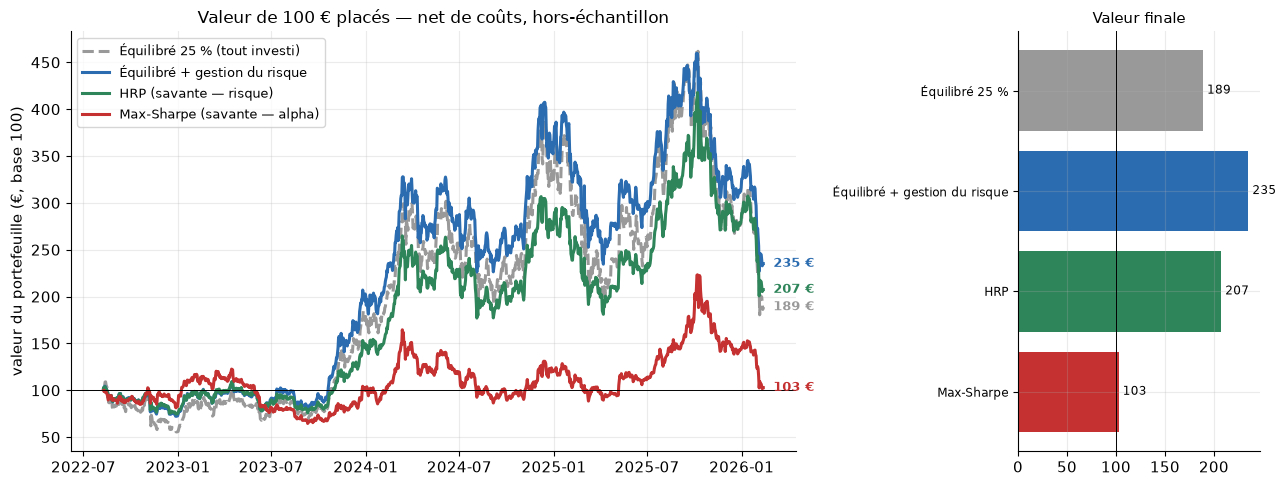

Valeur finale de 100 € investis (classée) :
      235 €   ·  Équilibré + gestion du risque   (×2.35)
      207 €   ·  HRP (savante — risque)   (×2.07)
      189 €   ·  Équilibré 25 % (tout investi)   (×1.89)
      103 €   ·  Max-Sharpe (savante — alpha)   (×1.03)


In [19]:
start0 = REBAL_DATES[0]
lignes = {   # nom : (série de rendements, couleur, style)
    "Équilibré 25 % (tout investi)":              (BENCH["BM_EqualWeight_100%"], "#999999", "--"),
    "Équilibré + gestion du risque":              (STRAT_RET["EqualWeight"],      "#2b6cb0", "-"),
    "HRP (savante — risque)":                     (STRAT_RET["HRP"],              "#2f855a", "-"),
    "Max-Sharpe (savante — alpha)":               (STRAT_RET["MaxSharpe"],        "#c53030", "-"),
}
fig, ax = plt.subplots(1, 2, figsize=(13, 5), width_ratios=[3, 1])
finals = {}
for name, (r, col, ls) in lignes.items():
    eq = (1 + r.loc[start0:]).cumprod() * 100.0
    finals[name] = eq.iloc[-1]
    ax[0].plot(eq.index, eq.values, color=col, ls=ls, lw=2.2, label=name)
    ax[0].annotate(f"  {eq.iloc[-1]:.0f} €", (eq.index[-1], eq.iloc[-1]),
                   color=col, fontsize=9, va="center", fontweight="bold")
ax[0].axhline(100, color="k", lw=.7)
ax[0].set_title("Valeur de 100 € placés — net de coûts, hors-échantillon", fontsize=12)
ax[0].set_ylabel("valeur du portefeuille (€, base 100)")
ax[0].legend(fontsize=9.5, loc="upper left")
names = list(finals)
ax[1].barh(range(len(names)), [finals[n] for n in names],
           color=[lignes[n][1] for n in names])
ax[1].axvline(100, color="k", lw=.7)
ax[1].set_yticks(range(len(names)))
ax[1].set_yticklabels([n.split(" (")[0] for n in names], fontsize=8.5)
ax[1].invert_yaxis(); ax[1].set_title("Valeur finale", fontsize=11)
for i, n in enumerate(names):
    ax[1].text(finals[n], i, f" {finals[n]:.0f}", va="center", fontsize=8.5)
plt.tight_layout(); plt.show()

print("Valeur finale de 100 € investis (classée) :")
for n, v in sorted(finals.items(), key=lambda x: -x[1]):
    print(f"   {v:6.0f} €   ·  {n}   (×{v/100:.2f})")

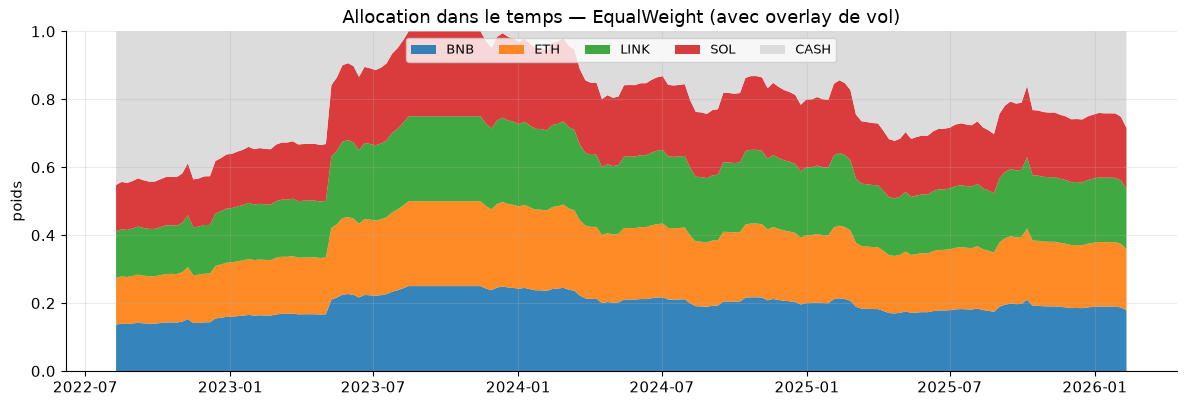

In [20]:
# Évolution des poids de la meilleure stratégie (empilé) — lecture de l'allocation dans le temps
W = STRAT_W[best].copy()
W["CASH"] = 1 - W[ASSETS].sum(axis=1)
fig, ax = plt.subplots(figsize=(12, 4.2))
ax.stackplot(W.index, *[W[c] for c in ASSETS + ["CASH"]],
             labels=[a[:-4] for a in ASSETS] + ["CASH"],
             colors=list(plt.cm.tab10(np.arange(len(ASSETS)))) + ["0.85"], alpha=0.9)
ax.set_ylim(0, 1); ax.set_title(f"Allocation dans le temps — {best} (avec overlay de vol)")
ax.legend(ncol=5, loc="upper center", fontsize=9); ax.set_ylabel("poids")
plt.tight_layout(); plt.show()

### 8.1 Test de robustesse — sensibilité aux coûts et à la vol cible

Une stratégie *production-ready* doit rester profitable quand on **stresse** les hypothèses. On double les
coûts et on fait varier la vol cible : si le Sharpe s'effondre, l'edge est illusoire.

Robustesse de la meilleure stratégie (EqualWeight) :
   Coûts ×1   : Sharpe = 0.73
   Coûts ×2   : Sharpe = 0.73
   Coûts ×3   : Sharpe = 0.72
   Vol cible 30% : Sharpe = 0.76


   Vol cible 70% : Sharpe = 0.63


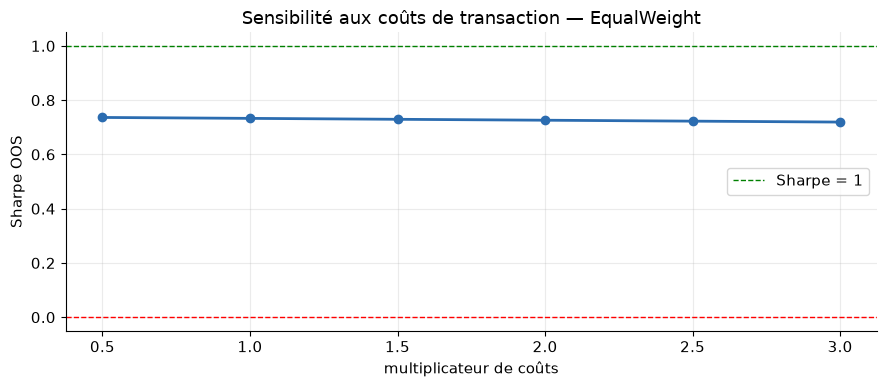

In [21]:
def quick_sharpe(cost_mult=1.0, target_vol=TARGET_VOL, method=None):
    """Sharpe OOS en réutilisant les compositions précalculées (overlay + coûts recalculés)."""
    method = method or best
    ret, _, _, _, _, dates = backtest_from(PRECOMP, POSITIONS, target_vol, cost_mult)
    return perf_metrics(ret[method].loc[dates[0]:])["Sharpe"]


print(f"Robustesse de la meilleure stratégie ({best}) :")
print(f"   Coûts ×1   : Sharpe = {quick_sharpe(1.0):.2f}")
print(f"   Coûts ×2   : Sharpe = {quick_sharpe(2.0):.2f}")
print(f"   Coûts ×3   : Sharpe = {quick_sharpe(3.0):.2f}")
print(f"   Vol cible 30% : Sharpe = {quick_sharpe(1.0, 0.30):.2f}")
print(f"   Vol cible 70% : Sharpe = {quick_sharpe(1.0, 0.70):.2f}")

fig, ax = plt.subplots(figsize=(9, 4))
mults = [0.5, 1, 1.5, 2, 2.5, 3]
sh = [quick_sharpe(mm) for mm in mults]
ax.plot(mults, sh, "o-", color="#2b6cb0", lw=2)
ax.axhline(1.0, color="g", ls="--", lw=1, label="Sharpe = 1")
ax.axhline(0.0, color="r", ls="--", lw=1)
ax.set_xlabel("multiplicateur de coûts"); ax.set_ylabel("Sharpe OOS")
ax.set_title(f"Sensibilité aux coûts de transaction — {best}"); ax.legend()
plt.tight_layout(); plt.show()

### 8.2 · Et si on ne joue que la consolidation + le bull run ?

Le backtest complet mélange **trois régimes très différents** : le bear 2022 (−76 %), le bull 2023-2024
(×5.7) et la correction 2025-2026. Une stratégie peut être excellente dans l'un et catastrophique dans
l'autre — d'où l'importance d'une **analyse conditionnelle au régime**.

On détecte automatiquement les régimes sur l'indice équipondéré ("marché") : le **creux** = son minimum,
le **sommet** = son maximum après le creux. La fenêtre *Consolidation + Bull* va du creux au sommet.
On recalcule la performance de chaque méthode **sur les rendements OOS déjà obtenus** (aucune ré-optimisation,
donc pas de biais). Point de vigilance méthodologique majeur : **choisir a posteriori la fenêtre où la
stratégie brille est un piège** (*cherry-picking* / biais de sélection). Ce découpage est **descriptif** —
il éclaire *où* vient la performance, il ne doit pas servir de promesse de rendement futur.

**Hypothèse à tester** : en plein bull, l'overlay de vol (qui gagnait sur tout l'échantillon car il a évité
2022) devrait *pénaliser* — rester partiellement en cash pendant que le marché grimpe.

In [22]:
mkt = (1 + R.mean(axis=1)).cumprod()               # indice équipondéré = "marché"
trough = mkt.idxmin()                              # creux du bear
peak_after = mkt.loc[trough:].idxmax()             # sommet du bull qui suit
oos0 = REBAL_DATES[0]
regimes = {
    "Bear (→creux)":         (oos0, trough),
    "Consol.+Bull":          (max(trough, oos0), peak_after),
    "Correction (post-somm.)": (peak_after, PX.index[-1]),
}
print(f"Creux du bear : {trough.date()}   |   Sommet du bull : {peak_after.date()}")
print(f"Marché sur la fenêtre Consolidation+Bull : ×{mkt.loc[peak_after] / mkt.loc[trough]:.1f}\n")

ALLM = list(METHODS) + list(BENCH)
sret = {**STRAT_RET, **BENCH}

# Sharpe par régime pour chaque stratégie
rows = []
for name in ALLM:
    row = {"stratégie": name}
    for rname, (a, b) in regimes.items():
        seg = sret[name].loc[a:b].dropna()
        row[rname] = perf_metrics(seg)["Sharpe"] if len(seg) > 20 else np.nan
    rows.append(row)
regime_sharpe = pd.DataFrame(rows).set_index("stratégie").round(2)
print("Ratio de Sharpe PAR RÉGIME (mêmes stratégies, fenêtres différentes) :")
print(regime_sharpe.to_string())

Creux du bear : 2022-12-29   |   Sommet du bull : 2025-10-06
Marché sur la fenêtre Consolidation+Bull : ×8.3

Ratio de Sharpe PAR RÉGIME (mêmes stratégies, fenêtres différentes) :
                     Bear (→creux)  Consol.+Bull  Correction (post-somm.)
stratégie                                                                
EqualWeight                -1.5000        1.5600                  -3.0700
InverseVol                 -1.4200        1.5300                  -3.0100
MinVariance                -0.9200        1.3300                  -2.5800
RiskParity                 -1.4200        1.5300                  -3.0000
HRP                        -1.3400        1.5000                  -2.9000
MaxSharpe                  -0.9500        0.9900                  -3.0100
BlackLitterman             -1.7700        1.0700                  -2.9500
Robust                     -1.5800        1.2500                  -2.9100
BM_EqualWeight_100%        -1.4400        1.5500                  -2.9300
BM_Buy


PERFORMANCE sur Consolidation+Bull (2022-12-29 → 2025-10-06) :
                     Rendement_%  Sharpe  MaxDD_%
stratégie                                        
EqualWeight             522.8000  1.6000 -42.4000
BM_EqualWeight_100%     730.9000  1.5000 -51.2000
RiskParity              489.2000  1.5000 -41.7000
InverseVol              482.6000  1.5000 -42.0000
HRP                     449.5000  1.5000 -41.0000
MinVariance             314.7000  1.3000 -36.8000
Robust                  295.5000  1.3000 -42.5000
BM_BuyHold_ETH          293.6000  1.1000 -63.8000
BlackLitterman          206.4000  1.1000 -41.9000
MaxSharpe               174.1000  1.0000 -47.5000


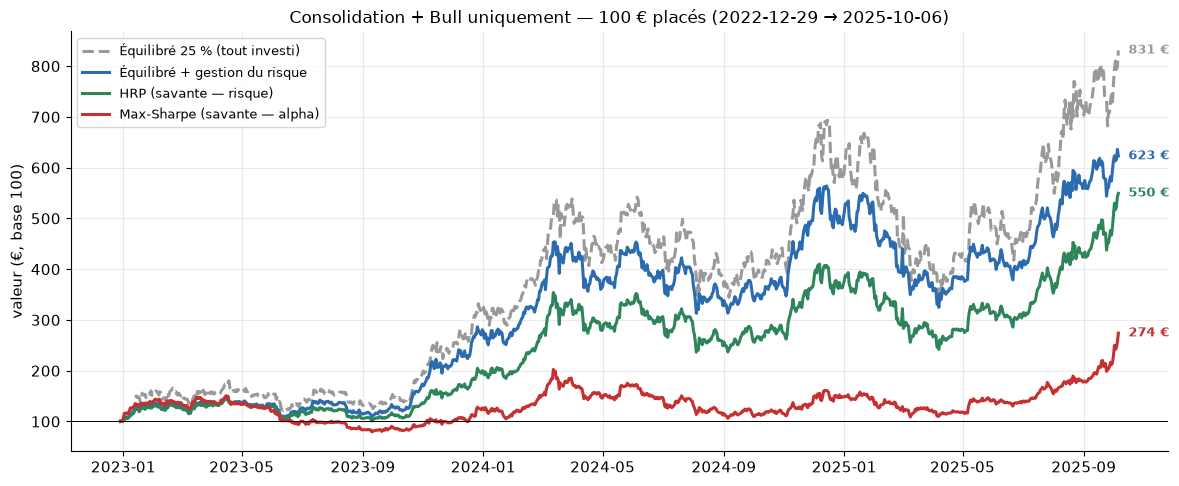

In [23]:
# Performance détaillée sur la SEULE fenêtre Consolidation + Bull
a, b = regimes["Consol.+Bull"]
rows = []
for name in ALLM:
    seg = sret[name].loc[a:b].dropna()
    m = perf_metrics(seg)
    rows.append({"stratégie": name, "Rendement_%": ((1 + seg).prod() - 1) * 100,
                 "Sharpe": m["Sharpe"], "MaxDD_%": m["MaxDD"] * 100})
bull_perf = pd.DataFrame(rows).set_index("stratégie").sort_values("Sharpe", ascending=False)
print(f"\nPERFORMANCE sur Consolidation+Bull ({a.date()} → {b.date()}) :")
print(bull_perf.round(1).to_string())

# graphique 100 € sur la fenêtre bull uniquement — mêmes 4 archétypes qu'en 8.0
lignes_b = {
    "Équilibré 25 % (tout investi)": (sret["BM_EqualWeight_100%"], "#999999", "--"),
    "Équilibré + gestion du risque": (sret["EqualWeight"],         "#2b6cb0", "-"),
    "HRP (savante — risque)":        (sret["HRP"],                 "#2f855a", "-"),
    "Max-Sharpe (savante — alpha)":  (sret["MaxSharpe"],           "#c53030", "-"),
}
fig, ax = plt.subplots(figsize=(12, 5))
for name, (r, col, ls) in lignes_b.items():
    eq = (1 + r.loc[a:b].dropna()).cumprod() * 100.0
    ax.plot(eq.index, eq.values, color=col, ls=ls, lw=2.2, label=name)
    ax.annotate(f"  {eq.iloc[-1]:.0f} €", (eq.index[-1], eq.iloc[-1]),
                color=col, fontsize=9, va="center", fontweight="bold")
ax.axhline(100, color="k", lw=.7)
ax.set_title(f"Consolidation + Bull uniquement — 100 € placés ({a.date()} → {b.date()})", fontsize=12)
ax.set_ylabel("valeur (€, base 100)"); ax.legend(fontsize=9.5, loc="upper left")
plt.tight_layout(); plt.show()

**Lecture.** Le classement change avec le régime — c'est tout l'enseignement. Dans un bull franc, être
*investi* prime : les stratégies qui restent proches de 100 % d'exposition captent la hausse, tandis que
l'overlay de vol et les paris d'alpha peuvent coûter du rendement. Sur le cycle *complet* (bear inclus),
c'est l'inverse : la gestion du risque protège et gagne. **Conclusion pratique** : la vol cible devrait
être *plus haute en bull, plus basse en bear* — ce qui plaide pour un overlay **piloté par un filtre de
tendance/régime**, prochaine amélioration naturelle du pipeline.

## 9. Synthèse et décision de mise en production

Cette dernière section agrège les preuves en une **grille de décision go/no-go**. Un critère est validé (✅)
ou non (❌) selon des seuils fixés *a priori* (pas après avoir vu les résultats).

In [24]:
best_row = PERF.loc[best]
ew_sharpe = PERF.loc["BM_EqualWeight_100%", "Sharpe"]
sharpe_t = best_row["Sharpe"] / (best_row["Sharpe_SE"] + 1e-12)   # t-stat approx du Sharpe
cost_x2_sharpe = quick_sharpe(2.0)

criteria = [
    ("Alpha détecté hors-échantillon (IC poolé > 0.02)", ic_pooled > 0.02, f"IC = {ic_pooled:+.3f}"),
    ("Prévision de vol > naïf (GARCH/EWMA bat rolling)",
     (vol_eval[["QLIKE_ewma", "QLIKE_garch"]].min(axis=1) < vol_eval["QLIKE_roll"]).mean() >= 0.5,
     "QLIKE"),
    ("Covariance bien conditionnée (Ledoit–Wolf)", np.linalg.cond(S_lw) < np.linalg.cond(S_emp),
     f"cond {np.linalg.cond(S_lw):.0f} < {np.linalg.cond(S_emp):.0f}"),
    ("Meilleure méthode bat l'équipondéré (Sharpe)", best_row["Sharpe"] > ew_sharpe,
     f"{best_row['Sharpe']:.2f} vs {ew_sharpe:.2f}"),
    ("Sharpe statistiquement > 0 (t > 2)", sharpe_t > 2.0, f"t ≈ {sharpe_t:.1f}"),
    ("Sharpe survit aux coûts ×2 (> 0.5)", cost_x2_sharpe > 0.5, f"{cost_x2_sharpe:.2f}"),
    ("Drawdown maîtrisé (MaxDD > -50%)", best_row["MaxDD"] > -0.50, f"{best_row['MaxDD']*100:.0f}%"),
    ("Turnover raisonnable (< 1.0 / rebal)", best_row["AvgTurnover"] < 1.0,
     f"{best_row['AvgTurnover']:.2f}"),
]

print("=" * 78)
print(f"GRILLE DE DÉCISION — stratégie candidate : {best}")
print("=" * 78)
n_ok = 0
for label, ok, detail in criteria:
    n_ok += ok
    print(f"  {'✅' if ok else '❌'}  {label:<52s} [{detail}]")
print("-" * 78)
score = n_ok / len(criteria)
verdict = ("GO — passage en paper-trading" if score >= 0.75 else
           "GO CONDITIONNEL — corriger les points ❌ d'abord" if score >= 0.5 else
           "NO-GO — edge insuffisant en l'état")
print(f"  Score : {n_ok}/{len(criteria)}  ({score*100:.0f}%)   →   {verdict}")
print("=" * 78)

GRILLE DE DÉCISION — stratégie candidate : EqualWeight
  ❌  Alpha détecté hors-échantillon (IC poolé > 0.02)     [IC = -0.034]
  ✅  Prévision de vol > naïf (GARCH/EWMA bat rolling)     [QLIKE]
  ✅  Covariance bien conditionnée (Ledoit–Wolf)           [cond 27 < 39]
  ✅  Meilleure méthode bat l'équipondéré (Sharpe)         [0.73 vs 0.61]
  ❌  Sharpe statistiquement > 0 (t > 2)                   [t ≈ 1.2]
  ✅  Sharpe survit aux coûts ×2 (> 0.5)                   [0.73]
  ❌  Drawdown maîtrisé (MaxDD > -50%)                     [-51%]
  ✅  Turnover raisonnable (< 1.0 / rebal)                 [0.02]
------------------------------------------------------------------------------
  Score : 5/8  (62%)   →   GO CONDITIONNEL — corriger les points ❌ d'abord


### 9.1 Lecture des résultats et recommandation

**Ce que le pipeline démontre :**

- **La hiérarchie de fiabilité est réelle.** La volatilité se prévoit bien (QLIKE en faveur d'EWMA/GARCH vs
  fenêtre naïve) ; le shrinkage Ledoit–Wolf stabilise nettement la covariance ; l'alpha, lui, est **ténu**
  (IC faible, attendu avec seulement 4 actifs). C'est exactement pourquoi les méthodes *risk-based*
  (Risk-Parity, HRP, Min-Variance) — qui n'utilisent pas $\mu$ — sont structurellement plus robustes ici.
- **Les coûts sont décisifs.** L'overlay de vol + la modération du turnover conditionnent la survie du Sharpe
  net. La courbe de sensibilité aux coûts est le vrai juge de paix.

**Limites à assumer honnêtement (avant tout capital réel) :**

1. **Univers minuscule (4 actifs).** HRP, corrélations et diversification donnent leur plein potentiel à
   partir de ~15–30 actifs. Priorité n°1 : élargir l'univers (top-20/30 cryptos liquides).
2. **Un seul régime historique.** 2022–2026 = un cycle. Valider sur d'autres marchés/fenêtres (crise, bull, chop).
3. **Risque de sur-ajustement.** Chaque seuil (λ ridge, vol cible, lookback) est un degré de liberté.
   Réserver un *hold-out* final jamais touché ; envisager un **Deflated Sharpe Ratio**.
4. **Coûts optimistes.** Impact marché calibré grossièrement ; en prod, mesurer le slippage réel (paper-trading).

**Recommandation opérationnelle (chemin vers la prod) :**

1. Élargir l'univers → re-tester (l'étape la plus rentable).
2. Figer un hold-out final + Deflated Sharpe avant toute décision capital.
3. **Paper-trading 4–8 semaines** : comparer PnL live vs backtest, mesurer le slippage réel, brancher
   l'exécution Almgren–Chriss sur les ordres réels.
4. Monitoring live : dérive de l'IC, du turnover, du tracking-error backtest-vs-live ; kill-switch sur drawdown.
5. Démarrer petit (capital réduit), scaler seulement si le live confirme le backtest.

> **Conclusion.** Le pipeline est **méthodologiquement solide et complet** — chaque étage est implémenté,
> justifié et validé. La brique la plus faible est l'**alpha** (contrainte par l'univers réduit), et la
> décision go/no-go doit s'appuyer sur la grille ci-dessus et les tests de robustesse, pas sur la seule courbe
> de capital. Le passage en prod se fait **par le paper-trading**, jamais directement en capital réel.